# Load Packages

In [1]:
using DifferentialEquations
using OrdinaryDiffEq
using DiffEqBase
using Sundials
using ODEInterfaceDiffEq
using Plots
using Measures
using CSV
using DataFrames
using EasyFit
using StatsPlots
using LinearAlgebra
using Random
using Distributions
using LsqFit
using BlackBoxOptim
using LaTeXStrings
using JLD2
using KernelDensity
using XLSX

In [2]:
xf1 = XLSX.readxlsx("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\Paper\\NoCO2Asseys\\NADH\\NADHNoCO2.xlsx")

XLSXFile("C:\IBECPostDocDrive\2024_01_16_NCvsKR\Paper\NoCO2Asseys\NADH\NADHNoCO2.xlsx") containing 1 Worksheet
            sheetname size          range        
-------------------------------------------------
         Result sheet 56x13         A1:M56       


In [3]:
XLSX.sheetnames(xf1)

1-element Vector{String}:
 "Result sheet"

In [4]:
sh1 = xf1["Result sheet"]

56×13 XLSX.Worksheet: ["Result sheet"](A1:M56) 

In [5]:
sh1["B44:M51"]

8×12 Matrix{Any}:
 0.3744  0.381   0.4695  0.5044  0.5723  …  0.4651  0.5159  0.541   0.6112
 0.502   0.4957  0.4395  0.5455  0.5408     0.517   0.6194  0.5316  0.5555
 0.5667  0.5382  0.4656  0.4858  0.5277     0.535   0.5583  0.2265  0.5408
 0.5638  0.4981  0.4934  0.5046  0.49       0.5311  0.6243  0.5438  0.5524
 0.54    0.542   0.5017  0.344   0.3474     0.5995  0.3465  0.3618  0.3599
 0.3923  0.3604  0.3484  0.3758  0.388   …  0.3816  0.3512  0.3447  0.317
 0.3964  0.3721  0.3427  0.338   0.3873     0.3872  0.3942  0.3629  0.3836
 0.5063  0.3906  0.3465  0.3803  0.3604     0.3468  0.3524  0.3517  0.3476

In [6]:
nhd1 = reshape(transpose(sh1["B44:M51"]),96);

nhd2 = sh1["B44:M51"];

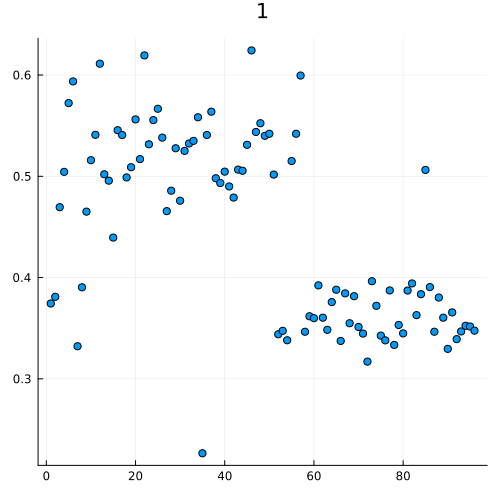

In [7]:
plot(scatter(nhd1, label = "", title = "1"), size=(500,500))

In [8]:
cal = (nhd1[7:12]+nhd1[7:12])./2

6-element Vector{Float64}:
 0.3322
 0.3904
 0.4651
 0.5159
 0.541
 0.6112

In [9]:
con = ((nhd1.-minimum(cal))/(maximum(cal)-minimum(cal)))*100;
conb = ((nhd2.-minimum(cal))/(maximum(cal)-minimum(cal)))*100;

In [10]:
TotNAD_C = vcat(reshape(transpose(conb[2:4, 1:6]), 3*6), conb[5,1:3]); # Total NAD for cells with CO2
NADH_Cpre = vcat(reshape(transpose(conb[6:8, 1:6]), 3*6), conb[5,4:6]); # NADH for cells with CO2
NADH_C = NADH_Cpre[vcat(1:12, 14:length(NADH_Cpre))] # Filter Otliers

TotNAD_NCpre = vcat(reshape(transpose(conb[2:4, 7:12]), 3*6), conb[5,7:9]); # Total NAD for cells without CO2 overnight
TotNAD_NC = TotNAD_NCpre[vcat(1:10, 12:length(TotNAD_NCpre))] # Filter Otliers
NADH_NCpre = vcat(reshape(transpose(conb[6:8, 7:12]), 3*6), conb[5,10:12]); # NADH for cells without CO2 overnight
NADH_NC = NADH_NCpre[vcat(1:12, 14:length(NADH_NCpre))]; # Filter Otliers

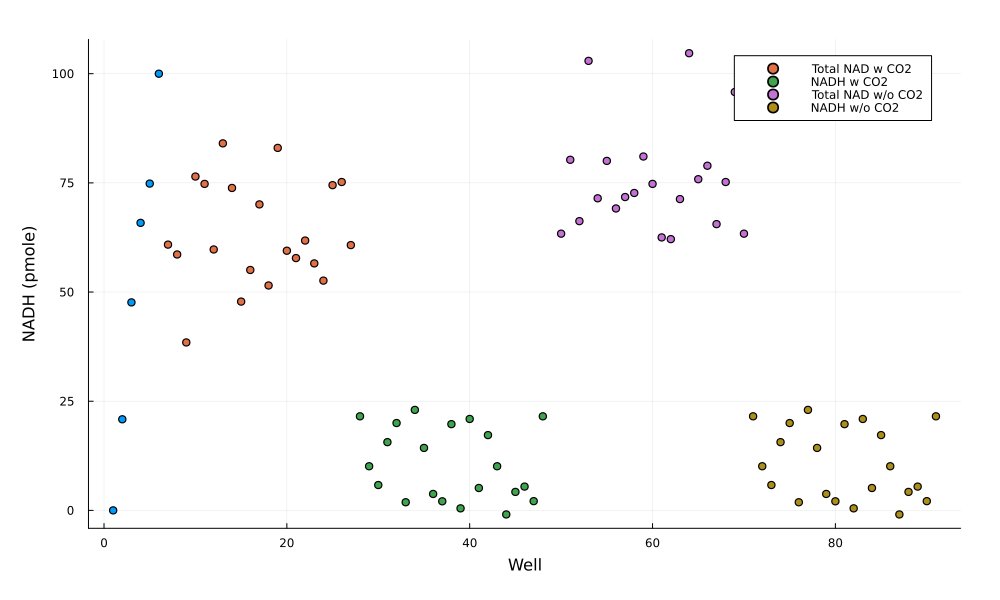

In [11]:
scatter(1:6, conb[1, 7:12], label = "", size=(1000,600), ylabel="NADH (pmole)", xlabel = "Well", margin = 8mm)

scatter!(7:length(TotNAD_C)+6, TotNAD_C, label = "Total NAD w CO2")
scatter!(7+length(TotNAD_C):length(NADH_C)+7+length(TotNAD_C), NADH_C, label = "NADH w CO2")

scatter!(50:length(TotNAD_NC)+50, TotNAD_NC, label = "Total NAD w/o CO2")
scatter!(length(TotNAD_NC)+51:length(NADH_NC)+51+length(TotNAD_NC), NADH_C, label = "NADH w/o CO2")

In [12]:
println("---------------- pmole Per Well with CO2 ----------------")
println("NAD_Tot w CO2:")
println("N("*string(mean(TotNAD_C))*", "*string(std(TotNAD_C))*")")
println("NADH w CO2:")
println("N("*string(mean(NADH_C))*", "*string(std(NADH_C))*")")

println("---------------- pmole Per Well without CO2 ----------------")
println("NAD_Tot w/o CO2:")
println("N("*string(mean(TotNAD_NC))*", "*string(std(TotNAD_NC))*")")
println("NADH w/o CO2:")
println("N("*string(mean(NADH_NC))*", "*string(std(NADH_NC))*")")

---------------- pmole Per Well with CO2 ----------------
NAD_Tot w CO2:
N(63.469875405359275, 11.967750088543566)
NADH w CO2:
N(10.129032258064518, 8.127577542280449)
---------------- pmole Per Well without CO2 ----------------
NAD_Tot w/o CO2:
N(76.28315412186382, 12.286356545538538)
NADH w/o CO2:
N(9.3494623655914, 6.885337851273709)


In [13]:
numCl = (2.5/6)*5 # For the test there should be 2.5 million cells in 5 mL of buffer media, but we used 6 mL for better distribution of sample. This conversion is to compute the actual number of cells used for the 5 mL distributed in the 96 well plate, which is a bit less. 

cpw = (numCl * 1e6)/(96-12) # Total number of cells per well

24801.587301587304

In [14]:
cfrr = 1e6/cpw

40.31999999999999

In [15]:
TotNAD_C2 = (TotNAD_C*1e6)/cpw; # Total NAD for cells with CO2
NADH_C2 = (NADH_C*1e6)/cpw; # NADH for cells with CO2

TotNAD_NC2 = (TotNAD_NC*1e6)/cpw; # Total NAD for cells without CO2 overnight
NADH_NC2 = (NADH_NC*1e6)/cpw;

In [16]:
println("---------------- pmole Per Million Cells with CO2 ----------------")
println("NAD_Tot:")
println("N("*string(mean(TotNAD_C2))*", "*string(std(TotNAD_C2))*")")
println("NADH:")
println("N("*string(mean(NADH_C2))*", "*string(std(NADH_C2))*")")

println("---------------- pmole Per Million Cells without CO2 ----------------")
println("NAD_Tot:")
println("N("*string(mean(TotNAD_NC2))*", "*string(std(TotNAD_NC2))*")")
println("NADH:")
println("N("*string(mean(NADH_NC2))*", "*string(std(NADH_NC2))*")")

---------------- pmole Per Million Cells with CO2 ----------------
NAD_Tot:
N(2559.105376344086, 482.5396835700766)
NADH:
N(408.4025806451614, 327.70392650474764)
---------------- pmole Per Million Cells without CO2 ----------------
NAD_Tot:
N(3075.7367741935486, 495.3858959161138)
NADH:
N(376.97032258064525, 277.61682216335595)


In [17]:
println("---------------- nmole Per Million Cells with CO2 ----------------")
println("NAD_Tot:")
println("N("*string(mean(TotNAD_C2./1e3))*", "*string(std(TotNAD_C2./1e3))*")")
println("NADH:")
println("N("*string(mean(NADH_C2./1e3))*", "*string(std(NADH_C2./1e3))*")")

println("---------------- nmole Per Million Cells without CO2 ----------------")
println("NAD_Tot:")
println("N("*string(mean(TotNAD_NC2./1e3))*", "*string(std(TotNAD_NC2./1e3))*")")
println("NADH:")
println("N("*string(mean(NADH_NC2./1e3))*", "*string(std(NADH_NC2./1e3))*")")

---------------- nmole Per Million Cells with CO2 ----------------
NAD_Tot:
N(2.5591053763440863, 0.4825396835700766)
NADH:
N(0.40840258064516133, 0.3277039265047476)
---------------- nmole Per Million Cells without CO2 ----------------
NAD_Tot:
N(3.0757367741935484, 0.49538589591611376)
NADH:
N(0.3769703225806452, 0.2776168221633559)


In [18]:
NADH1mil_C = NADH_C2./1e3;
NAD1mil_C = (TotNAD_C2./1e3) .- mean(NADH_C2./1e3);

NADH1mil_NC = NADH_NC2./1e3;
NAD1mil_NC = (TotNAD_NC2./1e3) .- mean(NADH_NC2./1e3);

In [141]:
JLD2.save("NAD_ProcData_nmoleper1M.jld", "NADH1mil_C", NADH1mil_C, "NAD1mil_C", NAD1mil_C, "NADH1mil_NC", NADH1mil_NC, "NAD1mil_NC", NAD1mil_NC)

In [ ]:
# CSV.write("E:\\IBEC\\KineticRates\\NoCO2Assays\\NADH_ProcData_nmoleper1M.csv",   DataFrame(reshape(NADH1mil_C, length(NADH1mil_C), 1), ["nmole for 1 million cell"]))
# CSV.write("E:\\IBEC\\KineticRates\\NoCO2Assays\\NAD_ProcData_nmoleper1M.csv",   DataFrame(reshape(NAD1mil_C, length(NAD1mil_C), 1), ["nmole for 1 million cell"]))

# CSV.write("E:\\IBEC\\KineticRates\\NoCO2Assays\\NADH_NoCO2_ProcData_nmoleper1M.csv",   DataFrame(reshape(NADH1mil_NC, length(NADH1mil_NC), 1), ["nmole for 1 million cell"]))
# CSV.write("E:\\IBEC\\KineticRates\\NoCO2Assays\\NAD_NoCO2_ProcData_nmoleper1M.csv",   DataFrame(reshape(NAD1mil_NC, length(NAD1mil_NC), 1), ["nmole for 1 million cell"]))

"E:\\IBEC\\KineticRates\\NoCO2Assays\\NAD_NoCO2_ProcData_nmoleper1M.csv"

In [129]:
celV = 850; # um^3 according to "In-depth quantitative analysis and comparison of the human hepatocyte and hepatoma cell line HepG2 proteomes"

In [130]:
celVL = celV*1e-15 # In Liters

8.500000000000001e-13

In [131]:
TotNAD_C3 = ((TotNAD_C2/(10^12))/celVL)*1000; # Total NAD for cells with CO2
NADH_C3 = ((NADH_C2/(10^12))/celVL)*1000; # NADH for cells with CO2

TotNAD_NC3 = ((TotNAD_NC2/(10^12))/celVL)*1000; # Total NAD for cells without CO2 overnight
NADH_NC3 = ((NADH_NC2/(10^12))/celVL)*1000;

In [132]:
println("---------------- uM per cell with CO2 ----------------")
println("NAD+:")
println("N("*string(mean((TotNAD_C3*1000)/1e6 .- mean((NADH_C3*1000)/1e6)))*", "*string(std((TotNAD_C3*1000)/1e6 .- mean((NADH_C3*1000)/1e6)))*")")
println("NADH:")
println("N("*string(mean((NADH_C3*1000)/1e6))*", "*string(std((NADH_C3*1000)/1e6))*")")

println("---------------- uM per cell without CO2 ----------------")
println("NAD+:")
println("N("*string(mean((TotNAD_NC3*1000)/1e6 .- mean((NADH_NC3*1000)/1e6)))*", "*string(std((TotNAD_NC3*1000)/1e6 .- mean((NADH_NC3*1000)/1e6)))*")")
println("NADH:")
println("N("*string(mean((NADH_NC3*1000)/1e6))*", "*string(std((NADH_NC3*1000)/1e6))*")")

---------------- uM per cell with CO2 ----------------
NAD+:
N(2530.2385831752053, 567.6937453765607)
NADH:
N(480.47362428842496, 385.534031182056)
---------------- uM per cell without CO2 ----------------
NAD+:
N(3175.0193548387097, 582.8069363718985)
NADH:
N(443.4944971537002, 326.6080260745363)


In [ ]:
con3 = ((con2/(10^12))/celVL)*1000;

In [ ]:
println("---------------- mM ----------------")
println("NAD_Tot:")
println("N("*string(mean(con3[13:52]))*", "*string(std(con3[13:52]))*")")
println("NADH:")
println("N("*string(mean(con3[70:96]))*", "*string(std(con3[70:96]))*")")

---------------- mM ----------------
NAD_Tot:
N(3.60338418493105e6, 1.2696523791882626e6)
NADH:
N(457122.55457109207, 238054.85110720957)


In [ ]:
println("---------------- uM 3 million ----------------")
println("NAD+:")
println("N("*string(mean(con3[13:52]*3*1000 .- mean(con3[70:96]*3*1000)))*", "*string(std(con3[13:52]*3*1000 .- mean(con3[70:96]*3*1000)))*")")
println("NADH:")
println("N("*string(mean(con3[70:96]*3*1000))*", "*string(std(con3[70:96]*3*1000))*")")

---------------- uM 3 million ----------------
NAD+:
N(9.438784891079874e9, 3.808957137564788e9)
NADH:
N(1.3713676637132761e9, 7.141645533216287e8)
